In [15]:
import numpy as np

# Cleaning parameters — adjust as needed
PARAMS = {
    # hard bounds
    "PRICE_MIN": 500,
    "PRICE_MAX": 100000,
    "MILEAGE_MIN": 0,
    "MILEAGE_MAX": 300000,
    "YEAR_MIN": 1985,
    "YEAR_MAX": 2025,

    # quantile trims
    "PRICE_Q_LOW": 0.01,
    "PRICE_Q_HIGH": 0.99,
    "MILEAGE_Q_LOW": 0.01,
    "MILEAGE_Q_HIGH": 0.99,

    # z-score cutoff per (make, model, year) group
    "LOGP_Z_MAX": 3.5,

    # rare model pruning
    "MIN_MODEL_COUNT": 20,

    # promotion switch
    "PROMOTE": False
}

# Paths
INPUT_CSV  = "/workspaces/used-car-price-app/data/clean_used_cars.csv"
CURATED_CSV = "/workspaces/used-car-price-app/data/clean_used_cars_curated.csv"
REPORT_JSON = "/workspaces/used-car-price-app/model/cleaning_report.json"

In [16]:
# ## 2. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os


In [17]:
# ## 3. Load & Preview
df = pd.read_csv(INPUT_CSV)
print("Initial shape:", df.shape)
df.head()


Initial shape: (255492, 9)


,price,year,mileage,make,model,body,age,mileage_per_year,high_mileage
0,19919.0,2019,46134.0,Tesla,Model 3,Coupe,6,7689.000000,0
1,19480.0,2024,16109.0,Nissan,Rogue,Sedan,1,16109.000000,0
2,4556.0,2018,173239.0,Hyundai,i20,Crossover,7,24748.428571,1
3,11536.0,2023,36810.0,Kia,Sportage,Hatchback,2,18405.000000,0
4,14098.0,2020,87749.0,Kia,Seltos,Pickup,5,17549.800000,0


In [18]:
def before_after_stats(df, title="Before Cleaning"):
    print(f"\n=== {title} ===")
    print(df.describe(include="all"))   # removed datetime_is_numeric
    print("\nTop 10 Makes:")
    if "make" in df.columns:
        print(df['make'].value_counts().head(10))
    print("\nTop 10 Models:")
    if "model" in df.columns:
        print(df['model'].value_counts().head(10))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    if "price" in df.columns:
        sns.histplot(df['price'], bins=50, ax=axes[0])
        axes[0].set_title("Price")
    if "mileage" in df.columns:
        sns.histplot(df['mileage'], bins=50, ax=axes[1])
        axes[1].set_title("Mileage")
    if "year" in df.columns:
        sns.histplot(df['year'], bins=40, ax=axes[2])
        axes[2].set_title("Year")
    plt.show()

In [19]:
removal_reasons = {}

def tally(reason, count):
    removal_reasons[reason] = removal_reasons.get(reason, 0) + count


In [20]:
before = len(df)
df = df[(df['make'].notna()) & (df['model'].notna())]
df = df[(df['make'] != "Unknown") & (df['model'] != "Unknown")]
tally("Unknown dropped", before - len(df))


In [21]:
before = len(df)
df = df[
    (df['price'].between(PARAMS["PRICE_MIN"], PARAMS["PRICE_MAX"])) &
    (df['mileage'].between(PARAMS["MILEAGE_MIN"], PARAMS["MILEAGE_MAX"])) &
    (df['year'].between(PARAMS["YEAR_MIN"], PARAMS["YEAR_MAX"]))
]
tally("Hard bounds", before - len(df))

In [22]:
# Step 3: Quantile trims
for col, qlow, qhigh in [
    ("price", PARAMS["PRICE_Q_LOW"], PARAMS["PRICE_Q_HIGH"]),
    ("mileage", PARAMS["MILEAGE_Q_LOW"], PARAMS["MILEAGE_Q_HIGH"])
]:
    before = len(df)
    lo, hi = df[col].quantile([qlow, qhigh])
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    tally(f"{col} quantile trim", before - len(df))


In [23]:
# Step 4: Groupwise log-price z-score filter
before = len(df)
df['log_price'] = np.log1p(df['price'])
df['zscore'] = df.groupby(['make','model','year'])['log_price'].transform(
    lambda x: (x - x.mean())/x.std(ddof=0)
)
df = df[df['zscore'].abs() <= PARAMS["LOGP_Z_MAX"]]
tally("Log-price z-score filter", before - len(df))


In [24]:
# Step 5: Rare model pruning
before = len(df)
model_counts = df['model'].value_counts()
rare_models = model_counts[model_counts < PARAMS["MIN_MODEL_COUNT"]].index
df = df[~df['model'].isin(rare_models)]
tally("Rare models", before - len(df))


Removals by reason:
Unknown dropped: 0
Hard bounds: 2696
price quantile trim: 5056
mileage quantile trim: 4952
Log-price z-score filter: 30103
Rare models: 23878
Final shape: (188807, 9)

=== After Cleaning ===
                price           year        mileage    make   model    body  \
count   188807.000000  188807.000000  188807.000000  188807  188807  107222   
unique            NaN            NaN            NaN      41    1133      21   
top               NaN            NaN            NaN    Ford  Mondeo   sedan   
freq              NaN            NaN            NaN   38580    4847   32540   
mean     14172.609628    2009.498848  108508.377179     NaN     NaN     NaN   
std      11634.113083       7.339202   58184.418515     NaN     NaN     NaN   
min        786.000000    1985.000000     194.000000     NaN     NaN     NaN   
25%       5500.000000    2005.000000   62977.500000     NaN     NaN     NaN   
50%      10500.000000    2011.000000  105561.000000     NaN     NaN     NaN  

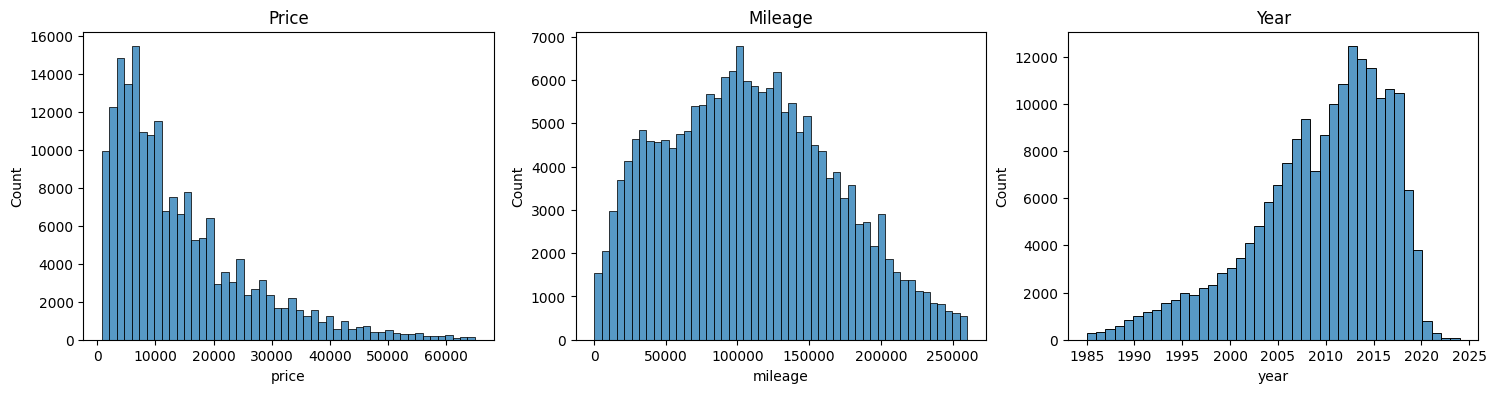

In [25]:
# Drop temp cols
df = df.drop(columns=["log_price","zscore"], errors="ignore")

print("\nRemovals by reason:")
for k,v in removal_reasons.items():
    print(f"{k}: {v}")
print("Final shape:", df.shape)

# ## 6. After Stats & Plots
before_after_stats(df, "After Cleaning")

In [26]:
df.to_csv(CURATED_CSV, index=False)

report = {
    "input_file": INPUT_CSV,
    "output_file": CURATED_CSV,
    "rows_removed": removal_reasons,
    "final_shape": df.shape,
    "params": PARAMS
}
os.makedirs(os.path.dirname(REPORT_JSON), exist_ok=True)
with open(REPORT_JSON, "w") as f:
    json.dump(report, f, indent=2)

print(f"\nCurated CSV written to {CURATED_CSV}")
print(f"Cleaning report written to {REPORT_JSON}")


Curated CSV written to /workspaces/used-car-price-app/data/clean_used_cars_curated.csv
Cleaning report written to /workspaces/used-car-price-app/model/cleaning_report.json


In [27]:
if PARAMS["PROMOTE"]:
    backup_path = INPUT_CSV.replace(".csv",".bak.csv")
    os.rename(INPUT_CSV, backup_path)
    os.rename(CURATED_CSV, INPUT_CSV)
    print(f"Promoted curated dataset. Backup saved at {backup_path}")

In [28]:
import os, json
for p in [INPUT_CSV, CURATED_CSV, REPORT_JSON]:
    print(os.path.abspath(p), "→", "FOUND" if os.path.exists(p) else "MISSING")

# peek the JSON summary
with open(REPORT_JSON) as f:
    rep = json.load(f)
print("\nRows removed by reason:", rep.get("rows_removed", {}))
print("Final shape:", rep.get("final_shape"))

/workspaces/used-car-price-app/data/clean_used_cars.csv → FOUND
/workspaces/used-car-price-app/data/clean_used_cars_curated.csv → FOUND
/workspaces/used-car-price-app/model/cleaning_report.json → FOUND

Rows removed by reason: {'Unknown dropped': 0, 'Hard bounds': 2696, 'price quantile trim': 5056, 'mileage quantile trim': 4952, 'Log-price z-score filter': 30103, 'Rare models': 23878}
Final shape: [188807, 9]
